# Bigram

In [1]:
import torch

In [2]:
with open('names.txt', 'r') as f:
    words = f.read().splitlines()

In [3]:
words[:20]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn',
 'abigail',
 'emily',
 'elizabeth',
 'mila',
 'ella',
 'avery',
 'sofia',
 'camila',
 'aria',
 'scarlett']

In [4]:
print(min([len(w) for w in words]))
print(max([len(w) for w in words]))

2
15


In [5]:
b = {}
for w in words[:]:
    chs =['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram  = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
        # print(ch1, ch2)

In [6]:
sorted(b.items(), key = lambda x: -x[1])

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('.', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '.'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('.', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '.'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('.', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '.'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('.', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('.', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('.', 'l'), 1572),
 (('.', 'c'), 1542),
 (('.', 'e'), 1531),
 (('j', 'a'), 1473),
 (('r', '.'), 1377),
 (('n', 'e'),

In [7]:
N = torch.zeros((27, 27), dtype= torch.int32)

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i  for i,s in enumerate(chars)}
stoi['.'] = 26
itos = {i: s for s,i in stoi.items()}


In [9]:
for w in words[:]:
    chs =['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        N[id1, id2] += 1

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline


In [11]:
itos

{0: 'a',
 1: 'b',
 2: 'c',
 3: 'd',
 4: 'e',
 5: 'f',
 6: 'g',
 7: 'h',
 8: 'i',
 9: 'j',
 10: 'k',
 11: 'l',
 12: 'm',
 13: 'n',
 14: 'o',
 15: 'p',
 16: 'q',
 17: 'r',
 18: 's',
 19: 't',
 20: 'u',
 21: 'v',
 22: 'w',
 23: 'x',
 24: 'y',
 25: 'z',
 26: '.'}

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

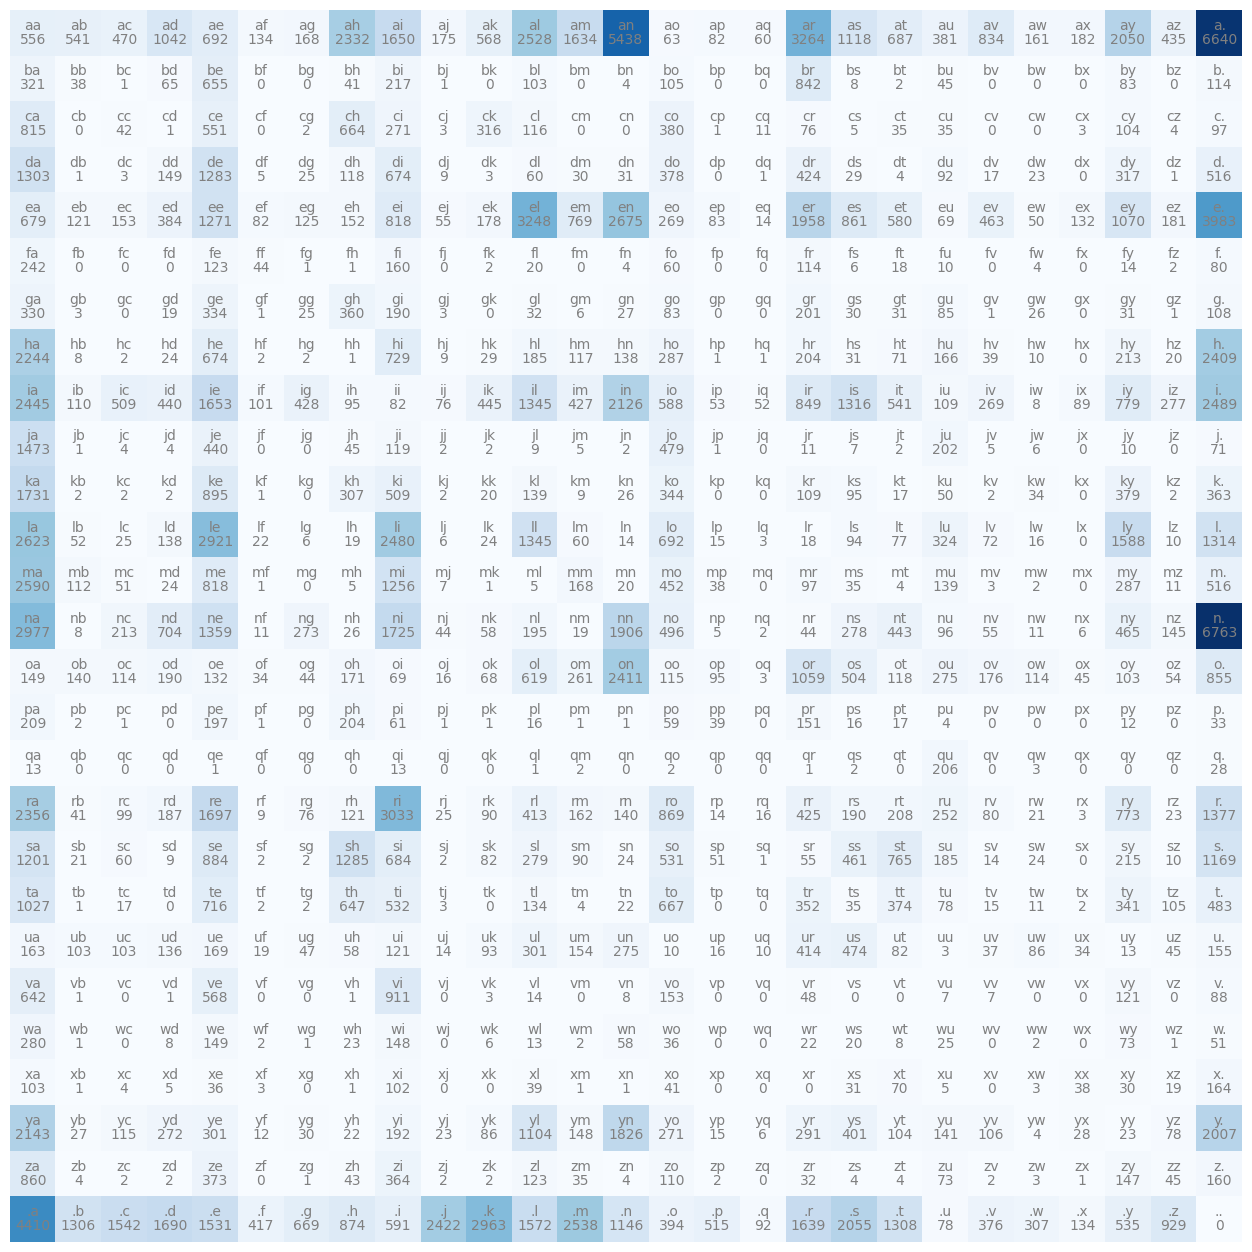

In [12]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap = 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha ='center', va = 'bottom', color = 'gray')
        plt.text(j, i, N[i,j].item(), ha ='center', va = 'top', color = 'gray')

plt.axis('off')

In [13]:
N[0,:]

tensor([ 556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568, 2528,
        1634, 5438,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,  182,
        2050,  435, 6640], dtype=torch.int32)

## Sample by using torch.multinomial

In [14]:
sf = 1 # smooth factor

In [15]:
P = (N+sf).float()

In [16]:
# Can broadcast?
# 27, 27
# 27, 1

In [17]:
P = P / P.sum(dim = 1 , keepdim = True)


In [18]:
P = P / P.sum(dim = 1 , keepdim = True)

In [19]:
ix = 26
g = torch.Generator().manual_seed(2147483647)
for i in range(10):
    name  = []
    while True:
        # p = p = N[ix].float()
        # p = p / p.sum()
        p = P[ix]
        # p = torch.ones(27) / 27 # to show how an total untrain model behave
        ix = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        if ix == 26:
            break
        name += [itos[ix]]
    print(''.join(name))

dry
na
kh
lvilend
lusien
m
jakanannn
l
el
lia


In [20]:
# Goal check how good is the model, use the  log likelihood
# If the data is likeli (large likelihood) under the model, then the model is good

In [21]:
log_likelihood = 0
n = 0
for w in words[:]:
    chs =['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        prob = P[id1, id2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
2.4543561935424805


# Use NN to predict the bigram

In [ ]:
# create the trainig set of bigrams (x, y

xs, ys = [], []

for w in words[:1]:
    chs =['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        xs.append(id1)
        ys.append(id2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [23]:
xs

tensor([26,  4, 12, 12,  0])

In [24]:
ys

tensor([ 4, 12, 12,  0, 26])

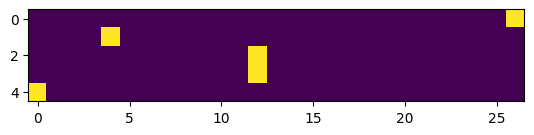

In [25]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes= 27).float()
yenc = F.one_hot(ys, num_classes= 27).float()
plt.imshow(xenc)

In [26]:
xenc.dtype

torch.float32

In [41]:
g = torch.Generator().manual_seed(2147483647)

In [28]:

W = torch.randn((27, 27), generator = g)
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)
probs

tensor([[0.0634, 0.0270, 0.0101, 0.0040, 0.0188, 0.0129, 0.0115, 0.0283, 0.0220,
         0.0805, 0.0116, 0.0218, 0.0112, 0.0253, 0.0204, 0.0370, 0.0389, 0.0270,
         0.0548, 0.0370, 0.0471, 0.0335, 0.0307, 0.1727, 0.0833, 0.0175, 0.0517],
        [0.0077, 0.0589, 0.0212, 0.0641, 0.0444, 0.0038, 0.0183, 0.0278, 0.0042,
         0.0403, 0.0918, 0.1240, 0.0212, 0.0325, 0.0324, 0.0046, 0.0169, 0.0683,
         0.0085, 0.0224, 0.0655, 0.0981, 0.0273, 0.0274, 0.0065, 0.0073, 0.0549],
        [0.0107, 0.0173, 0.0445, 0.0068, 0.0278, 0.0232, 0.0120, 0.0329, 0.0381,
         0.0135, 0.0051, 0.0085, 0.0365, 0.0234, 0.0411, 0.0290, 0.1845, 0.0757,
         0.0110, 0.0143, 0.0261, 0.1264, 0.0338, 0.0737, 0.0293, 0.0383, 0.0167],
        [0.0107, 0.0173, 0.0445, 0.0068, 0.0278, 0.0232, 0.0120, 0.0329, 0.0381,
         0.0135, 0.0051, 0.0085, 0.0365, 0.0234, 0.0411, 0.0290, 0.1845, 0.0757,
         0.0110, 0.0143, 0.0261, 0.1264, 0.0338, 0.0737, 0.0293, 0.0383, 0.0167],
        [0.0607, 0.0100,

In [29]:
probs.shape

torch.Size([5, 27])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
xenc = F.one_hot(xs, num_classes= 27).float()
yenc = F.one_hot(ys, num_classes= 27).float()
W = torch.randn((27, 27), generator = g, requires_grad= True)


In [62]:
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims = True)

In [63]:
loss = -probs[torch.arange(len(xs)), ys].log().mean()
print(f'{loss.item():.3f}')

3.500


In [58]:
W.grad = None
loss.backward()

In [61]:
W.data += -0.1 * W.grad

In [71]:
xs, ys = [], []

for w in words[:]:
    chs =['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        id1 = stoi[ch1]
        id2 = stoi[ch2]
        xs.append(id1)
        ys.append(id2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xenc = F.one_hot(xs, num_classes= 27).float()
yenc = F.one_hot(ys, num_classes= 27).float()

In [81]:
alpha = 50
for k in range(100):
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims = True)

    loss = -probs[torch.arange(len(xs)), ys].log().mean()
    if k % 10 == 0:
        print(f'{loss.item():.3f}')

    W.grad = None
    loss.backward()

    W.data += -alpha * W.grad

2.470
2.468
2.467
2.466
2.465
2.464
2.464
2.463
2.463
2.462


## sample de results

In [85]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    name  = []
    ix = 26
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes= 27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims = True)
        ix = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g).item()
        
        if ix == 26:
            break
        name += [itos[ix]]
    print(''.join(name))

dry
na
kh
lvilend
leyien
